In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('dataset_esercitazione.csv')
print(data.shape)
target = data['dzgroup']
data = data.drop(columns=['dzgroup', 'dzclass'])
X_train, X_temp, y_train, y_temp = train_test_split(data, target, test_size=0.2, random_state=42, stratify=target)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

nan_percentage = X_train.isna().sum() / X_train.shape[0] * 100
print(f"Percentuale di nan nei dati: {nan_percentage.sort_values(ascending=False)}%")

(9105, 43)
Percentuale di nan nei dati: adlp        61.957716
urine       53.542010
glucose     49.766612
bun         48.091708
totmcst     38.248215
alb         37.040088
income      32.880286
adls        31.438770
bili        29.022515
pafi        25.604064
ph          25.082372
prg2m       18.190555
prg6m       17.984624
edu         17.915980
totcst       9.678748
wblc         2.388797
charges      1.935750
avtisst      0.974739
crea         0.727622
race         0.466776
dnr          0.329489
dnrday       0.329489
sps          0.013729
resp         0.013729
scoma        0.013729
sod          0.013729
hrt          0.013729
meanbp       0.013729
temp         0.013729
surv2m       0.013729
surv6m       0.013729
aps          0.013729
age          0.000000
num.co       0.000000
sex          0.000000
hday         0.000000
diabetes     0.000000
ca           0.000000
dementia     0.000000
adlsc        0.000000
death        0.000000
dtype: float64%


In [9]:
threshold = 15 

cols_to_drop = nan_percentage[nan_percentage > threshold].index
print(cols_to_drop)

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)

print(f"Nuovo numero di colonne: {X_train.shape[1]}")

Index(['edu', 'income', 'totmcst', 'prg2m', 'prg6m', 'pafi', 'alb', 'bili',
       'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls'],
      dtype='object')
Nuovo numero di colonne: 27


In [10]:
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

for df in [X_val, X_test]:
    df[num_cols] = num_imputer.transform(df[num_cols])
    df[cat_cols] = cat_imputer.transform(df[cat_cols])
    
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_val[cat_cols] = encoder.transform(X_val[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)


from sklearn.preprocessing import StandardScaler
# Codificando con ordinal Encoding le feature categoriche ora hanno un ordinamento numerico. Devo scalarle per evitare che il modello dia più importanza a quelle con valori più alti.
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [11]:
print(type(y_train))

<class 'numpy.ndarray'>


In [12]:
corr = X_train.corrwith(pd.Series(y_train, index=X_train.index)).abs()
print(corr.sort_values(ascending=False))

surv6m      0.377034
ca          0.348049
death       0.267228
surv2m      0.267180
dnrday      0.223030
totcst      0.190499
avtisst     0.189145
charges     0.188757
aps         0.158923
dnr         0.136438
diabetes    0.130433
scoma       0.086702
sps         0.084742
crea        0.074453
num.co      0.072133
dementia    0.062857
hday        0.058097
wblc        0.039014
meanbp      0.034887
race        0.034237
age         0.032484
temp        0.029883
sod         0.028784
resp        0.018809
adlsc       0.013380
hrt         0.010327
sex         0.000688
dtype: float64


In [13]:
corr = X_train.corr()

columns = corr.columns

for i in range(len(columns)):
    for j in range(i+1, len(columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"Colonne {columns[i]} e {columns[j]} sono altamente correlate con coefficiente di correlazione: {corr.iloc[i, j]}")

Colonne charges e totcst sono altamente correlate con coefficiente di correlazione: 0.7392528080925291
Colonne sps e aps sono altamente correlate con coefficiente di correlazione: 0.7971296660128568
Colonne sps e surv2m sono altamente correlate con coefficiente di correlazione: -0.7590649548352068
Colonne surv2m e surv6m sono altamente correlate con coefficiente di correlazione: 0.9604158328199266


In [14]:
highly_correlated = [['charges', 'totcst'], ['sps', 'aps'], ['surv2m', 'surv6m']]

for cols in highly_correlated:
    for df in [X_train, X_val, X_test]:
        df['_'.join(cols)] = df[cols].mean(axis=1)
        df.drop(columns=cols, inplace=True)
        
print(X_train.columns.tolist())

['age', 'sex', 'num.co', 'scoma', 'avtisst', 'race', 'hday', 'diabetes', 'dementia', 'ca', 'dnr', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'crea', 'sod', 'adlsc', 'death', 'charges_totcst', 'sps_aps', 'surv2m_surv6m']


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "criterion": ['gini', 'log_loss'],
    "min_samples_split": [2, 5, 10],
    'max_features': ['sqrt', 5]
}

rf = RandomForestClassifier(random_state=42)
gs = GridSearchCV(rf, params, scoring='accuracy', cv=5, verbose=1)
gs.fit(X_train, y_train)

print("Migliori parametri:", gs.best_params_)
print("Migliore score:", gs.best_score_)

print("Miglior score sulla validation set:", gs.score(X_val, y_val))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Migliori parametri: {'criterion': 'log_loss', 'max_features': 5, 'min_samples_split': 5}
Migliore score: 0.7123841326826914
Miglior score sulla validation set: 0.7406593406593407


In [18]:
import torch
from torch import nn
import torchnn as utils
from torch.utils.data import Dataset
import numpy as np

class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.X = self.X.unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
train_dataloader, val_dataloader, test_dataloader = utils.make_dataloaders(
    MyDataset(np.array(X_train), np.array(y_train)),
    MyDataset(np.array(X_val), np.array(y_val)),
    MyDataset(np.array(X_test), np.array(y_test)),
)
        

/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape e tipo dei campioni: torch.Size([64, 1, 24]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


In [19]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv1d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Flatten(),
            
            nn.Linear(64 * (X_train.shape[1] // 2), 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, len(label_encoder.classes_)),
            nn.LogSoftmax(dim=1)
        )
        
    def forward(self, x):
        return self.layers(x)
import copy
        
class SaveBestModel():
    def __init__(self):
        self.best_model_state = None
        self.best_optimizer_state = None
        self.best_loss = float('inf')
        
    def __call__(self, epoch_loss, model, optimizer, train_loss, val_loss, test_loss, accuracy):
        if epoch_loss < self.best_loss:
            self.best_loss = epoch_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.best_optimizer_state = copy.deepcopy(optimizer.state_dict())
            self.train_loss = train_loss
            self.val_loss = val_loss
            self.test_loss = test_loss
            self.accuracy = accuracy
            
    def save(self, path):
        torch.save({
            "model_state_dict": self.best_model_state,
            "optimizer_state_dict": self.best_optimizer_state,
            "train_loss": self.train_loss,
            "val_loss": self.val_loss,
            "test_loss": self.test_loss,
            "accuracy": self.accuracy
        },path)

In [20]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

def eval_loop(model, dataloader, device, loss_fn):
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0.0, 0

    y_true = []
    y_pred = []
    y_pred_proba = []
    # context manager che disabilita esplicitamente il calcolo dei gradienti in fase di test
    with torch.no_grad():
        for X, y in dataloader:

            # Spostiamo esplicitamente i tensori sul device di computazione
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            # L'accuracy sul batch si calcola creando il tensore di dimensione pari al batch
            # per cui i massimi argomenti di ogni predizione sono uguali alla classe predetta
            # per il singolo campione, poi convertendo questo tensore di booleani in un vettore
            # binario di tipo float, sommando i valori 1 ed estraendo lo scalare contenuto nel tensore risultato
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.argmax(1).cpu().numpy())
            y_pred_proba.extend(torch.exp(pred).cpu().numpy())

    test_loss /= num_batches
    accuracy /= size            # Per quanto detto prima, l'accuracy media va calcolata sulla dimensione del data set

    epoch_metrics = {}

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    
    epoch_metrics['f1_score'] = f1_score(y_true, y_pred, average='weighted')
    epoch_metrics['precision'] = precision_score(y_true, y_pred, average='weighted')
    epoch_metrics['recall'] = recall_score(y_true, y_pred, average='weighted')
    epoch_metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='weighted')

    return test_loss, accuracy, epoch_metrics, (y_true, y_pred, y_pred_proba)

In [21]:
from tqdm import trange
epochs = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Net().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.NLLLoss()
save_best_model = SaveBestModel()
early_stopper = utils.EarlyStopping(patience=5, min_delta=0.01)
train_loss = []
val_loss = []
test_loss = []
accuracy = []

train_batches = len(train_dataloader.batch_sampler)
for epoch in range(1, epochs+1):
    pbar = trange(train_batches)
    pbar.set_description(desc='Epoch {:4d}'.format(epoch))
    
    epoch_train_loss = utils.train_loop(model, train_dataloader, optimizer, device, pbar, loss_fn=criterion)
    train_loss.append(epoch_train_loss)
    
    epoch_val_loss, val_acc, val_metrics, _ = eval_loop(model, val_dataloader, device, criterion)
    val_loss.append(epoch_val_loss)
    accuracy.append(val_acc)
    
    epoch_test_loss, test_acc, test_metrics, _ = eval_loop(model, test_dataloader, device, criterion)
    test_loss.append(epoch_test_loss)
    
    print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f}, val_loss={epoch_val_loss:.4f}, val_acc={val_acc:.4f}, test_loss={epoch_test_loss:.4f}\nval_accuracy={val_acc:.4f}")
    
    save_best_model(epoch_val_loss, model, optimizer, epoch_train_loss, epoch_val_loss, epoch_test_loss, val_acc)
    early_stopper(epoch_val_loss)
    
    if early_stopper.early_stop:
        print("Early stopping")
        break
    
    

Epoch    1:   0%|          | 0/114 [00:00<?, ?it/s]/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch    1: 100%|██████████| 114/114 [00:05<00:00, 20.94it/s]
/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1: train_loss=1.2171, val_loss=0.8623, val_acc=0.6824, test_loss=0.8407
val_accuracy=0.6824


Epoch    2:   0%|          | 0/114 [00:00<?, ?it/s]/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch    2: 100%|██████████| 114/114 [00:00<00:00, 163.63it/s]
/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2: train_loss=0.8255, val_loss=0.7777, val_acc=0.7220, test_loss=0.7267
val_accuracy=0.7220


Epoch    3:   0%|          | 0/114 [00:00<?, ?it/s]/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch    3: 100%|██████████| 114/114 [00:00<00:00, 156.70it/s]
/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 15: train_loss=0.4470, val_loss=0.6655, val_acc=0.7692, test_loss=0.6811
val_accuracy=0.7692


Epoch   16:   0%|          | 0/114 [00:00<?, ?it/s]/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch   16: 100%|██████████| 114/114 [00:00<00:00, 187.35it/s]
/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 16: train_loss=0.4401, val_loss=0.6213, val_acc=0.7747, test_loss=0.6837
val_accuracy=0.7747


Epoch   17:   0%|          | 0/114 [00:00<?, ?it/s]/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch   17: 100%|██████████| 114/114 [00:00<00:00, 179.90it/s]
/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 17: train_loss=0.4108, val_loss=0.6771, val_acc=0.7637, test_loss=0.7177
val_accuracy=0.7637
Early stopping


/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text(0.5, 1.0, 'NN')

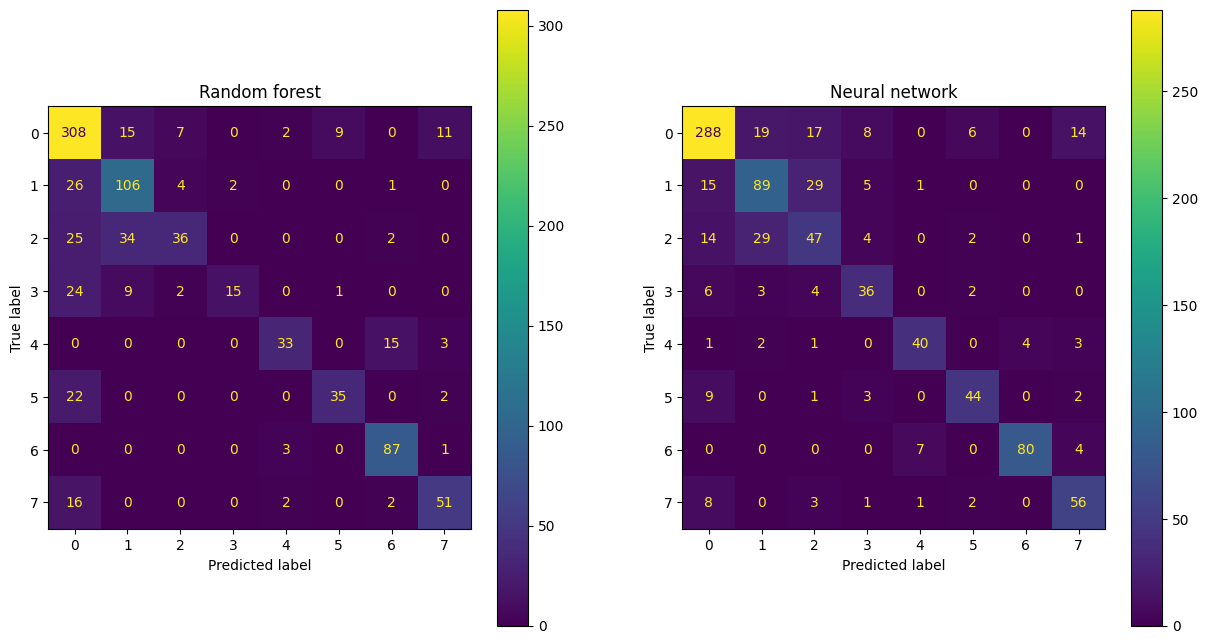

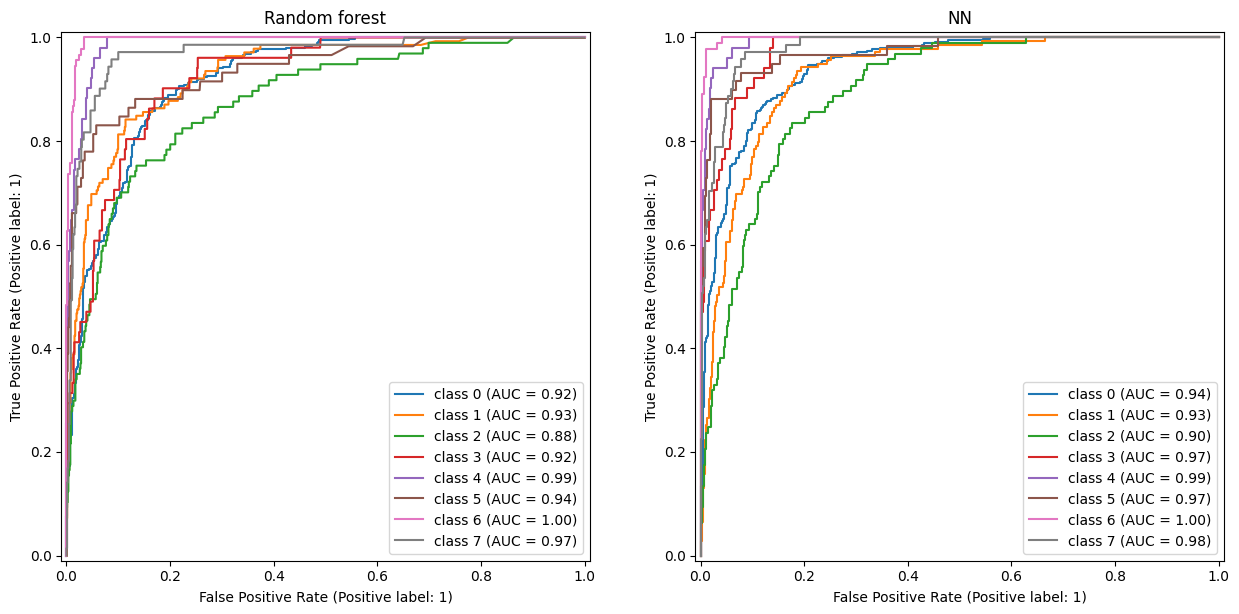

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import label_binarize

model.load_state_dict(save_best_model.best_model_state)

y_pred_rf = gs.best_estimator_.predict(X_test)
y_pred_proba_rf = gs.best_estimator_.predict_proba(X_test)
_, _, _, (y_true_nn, y_pred_nn, y_pred_proba_nn) = eval_loop(model, test_dataloader, device, criterion)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15,8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[0])
ax[0].set_title('Random forest')

ConfusionMatrixDisplay.from_predictions(y_true_nn, y_pred_nn, ax=ax[1])
ax[1].set_title('Neural network')
n_classes = len(label_encoder.classes_)
y_test_rf_bin = label_binarize(y_test, classes=np.arange(n_classes))
y_true_nn_bin = label_binarize(y_true_nn, classes=np.arange(n_classes))

fig, ax = plt.subplots(1, 2, figsize=(15,8))
for cls in range(n_classes):
    RocCurveDisplay.from_predictions(y_test_rf_bin[:,cls], y_pred_proba_rf[:,cls], ax=ax[0], name=f"class {cls}")
    RocCurveDisplay.from_predictions(y_true_nn_bin[:,cls], y_pred_proba_nn[:,cls], ax=ax[1], name=f"class {cls}")

ax[0].set_title('Random forest')
ax[1].set_title('NN')



In [23]:
auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='macro')
auc_nn = roc_auc_score(y_true_nn, y_pred_proba_nn, multi_class='ovr', average='macro')

print(f"AUC Random Forest: {auc_rf:.4f}")
print(f"AUC Neural Network: {auc_nn:.4f}")

AUC Random Forest: 0.9423
AUC Neural Network: 0.9609
